# Hyperparameter Tuning Strategies
### Hands-on Notebook

**Learning Objectives**
1. Implement **Grid Search** for parameter optimization
2. Search the **parameter space systematically**

---
A decision tree predicting ad clicks, left on its defaults, grows to depth 10 and overfits. We'll use `GridSearchCV` to systematically search for a better configuration.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

np.random.seed(9)


## 1. The ad-click dataset


In [2]:
n = 300
ad_position = np.random.uniform(0, 1, n)
time_of_day = np.random.uniform(0, 24, n)
category_match = np.random.uniform(0, 1, n)
image_quality = np.random.uniform(0, 1, n)
noise1 = np.random.uniform(0, 100, n)
noise2 = np.random.uniform(0, 100, n)

z = 2.5*ad_position + 3*category_match + 1.2*image_quality - 0.05*(time_of_day-14)**2 - 2.0
prob_click = 1 / (1 + np.exp(-z))
clicked = (np.random.rand(n) < prob_click).astype(int)

df = pd.DataFrame({
    "ad_position": ad_position, "time_of_day": time_of_day,
    "category_match": category_match, "image_quality": image_quality,
    "noise1": noise1, "noise2": noise2, "clicked": clicked,
})
X, y = df.drop(columns="clicked").values, df["clicked"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"{n} ads, click rate: {y.mean():.2f}")


300 ads, click rate: 0.41


## 2. The default model overfits

Left on every default setting, the tree grows as deep as it needs to perfectly fit the training data.


In [3]:
default_tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
default_acc = accuracy_score(y_test, default_tree.predict(X_test))

print(f"Tree depth chosen by default: {default_tree.get_depth()}")
print(f"Test accuracy: {default_acc:.3f}")


Tree depth chosen by default: 10
Test accuracy: 0.667


**Checkpoint:** this should match the slide — depth 10, test accuracy ≈ 0.667.


## 3. Grid Search — trying every combination systematically

`GridSearchCV` takes a dictionary of hyperparameter names to candidate value lists, forms every combination, and scores each one with cross-validation automatically.


In [4]:
param_grid = {
    "max_depth": [2, 4, 6],
    "min_samples_leaf": [1, 5, 10],
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 3))


Best params: {'max_depth': 6, 'min_samples_leaf': 10}
Best CV accuracy: 0.756


In [5]:
results = pd.DataFrame(grid.cv_results_)[["param_max_depth", "param_min_samples_leaf", "mean_test_score", "std_test_score"]]
results.columns = ["max_depth", "min_samples_leaf", "mean_cv_accuracy", "std"]
results.sort_values("mean_cv_accuracy", ascending=False).round(3)


,max_depth,min_samples_leaf,mean_cv_accuracy,std
8,6,10,0.756,0.051
5,4,10,0.747,0.046
6,6,1,0.733,0.054
4,4,5,0.711,0.040
7,6,5,0.702,0.023
3,4,1,0.698,0.030
1,2,5,0.689,0.073
2,2,10,0.689,0.073
0,2,1,0.676,0.065


**Checkpoint:** this should match the slide's full 9-row grid — best combination `max_depth=6, min_samples_leaf=10` with mean CV accuracy ≈ 0.756.


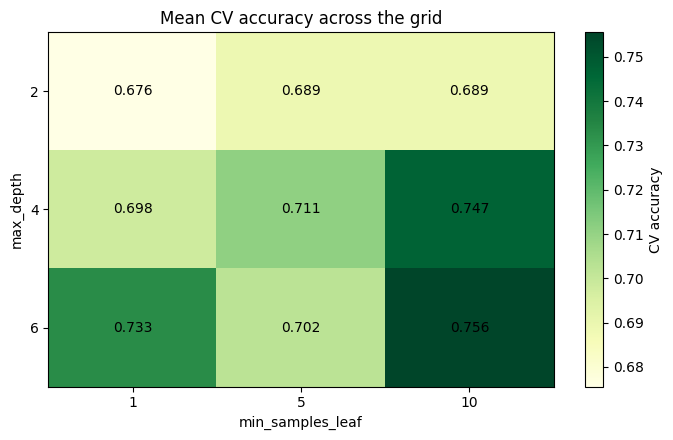

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
pivot = results.pivot(index="max_depth", columns="min_samples_leaf", values="mean_cv_accuracy")
im = ax.imshow(pivot.values, cmap="YlGn", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xlabel("min_samples_leaf"); ax.set_ylabel("max_depth")
ax.set_title("Mean CV accuracy across the grid")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i,j]:.3f}", ha="center", va="center", color="black", fontsize=10)
plt.colorbar(im, ax=ax, label="CV accuracy")
plt.tight_layout(); plt.show()


## 4. Confirming the improvement on held-out data

`grid.best_estimator_` is already refit on the full training set with the winning hyperparameters — we just need to score it on the test set.


In [7]:
best_test_acc = accuracy_score(y_test, grid.best_estimator_.predict(X_test))

print(f"Default (unlimited depth):  {default_acc:.3f}")
print(f"Grid Search best:           {best_test_acc:.3f}")


Default (unlimited depth):  0.667
Grid Search best:           0.827


**Checkpoint:** this should match the slide — default 0.667, tuned 0.827.


## 5. Exercises


**Exercise 1.** Add `"min_samples_split": [2, 10]` to `param_grid` and rerun Grid Search. How many total configurations does the grid now cover, and does the best combination change?


In [8]:
# TODO



<details><summary>Solution</summary>

```python
param_grid_v2 = {
    "max_depth": [2, 4, 6],
    "min_samples_leaf": [1, 5, 10],
    "min_samples_split": [2, 10],
}
grid_v2 = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_v2, cv=5)
grid_v2.fit(X_train, y_train)
print(len(grid_v2.cv_results_["params"]))  # 3 x 3 x 2 = 18 configurations
print(grid_v2.best_params_)
```
The grid grows from 9 to 18 configurations — adding one more hyperparameter with 2 values multiplies, rather than adds to, the total search size.
</details>


**Exercise 2.** Using `results`, write one line to find the configuration with the *worst* mean CV accuracy.


In [9]:
# TODO



<details><summary>Solution</summary>

```python
print(results.loc[results["mean_cv_accuracy"].idxmin()])
```
</details>


**Exercise 3.** `GridSearchCV` has a `refit=True` default, meaning `grid.best_estimator_` is retrained on the *entire* training set using the winning hyperparameters (not just whichever fold happened to score it). Confirm this by checking that `grid.best_estimator_.get_depth()` differs from any single fold's tree by comparing the number of training rows each would have seen.


In [10]:
# TODO



<details><summary>Solution</summary>

```python
print("Rows used by best_estimator_ (full training set):", len(X_train))
print("Rows used by one CV fold during search:", len(X_train) * 4 // 5)  # 4/5 folds used for training each round
```
The final `best_estimator_` is refit on all of `X_train`, not just the 4/5 used within cross-validation — cross-validation is only used to *choose* the hyperparameters, not to produce the final model.
</details>


## 6. Recap

- **Hyperparameters** are configuration choices set before training, not values the model learns on its own.
- **Grid Search** forms every combination of candidate values across all hyperparameters being tuned, and scores each one with cross-validation.
- The grid's size multiplies with every added hyperparameter or value — a small grid can already mean dozens of model fits.
- The winning configuration, refit on the full training set, delivered a large, verified improvement over the untuned default — 0.667 to 0.827 test accuracy here.
